타이타닉 탑승자의 생존을 판단하는 모델을 만들어 보자!

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno


In [13]:
TRAIN = pd.read_csv('./data/titanic/train.csv', encoding='utf-8')
TEST = pd.read_csv('./data/titanic/test.csv', encoding='utf-8')

#### EDA

In [14]:
TRAIN.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


<Axes: >

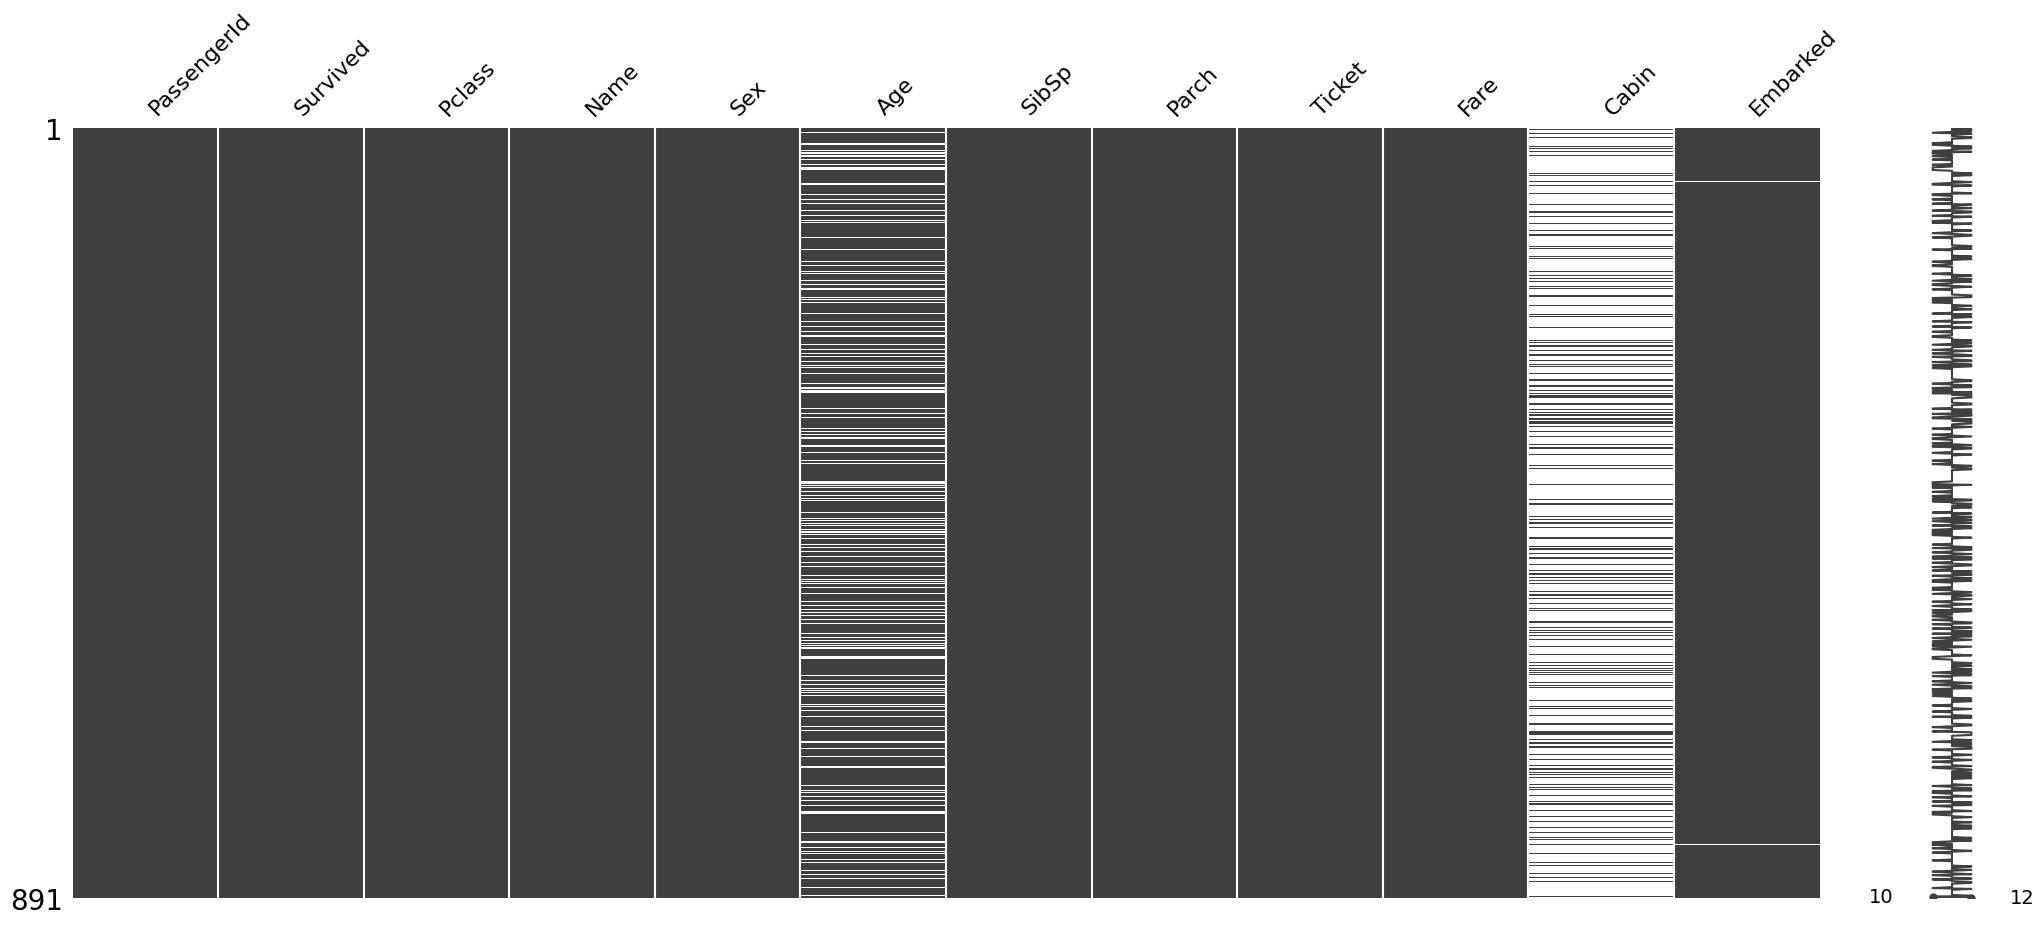

In [15]:
missingno.matrix(TRAIN)

<Axes: xlabel='Embarked'>

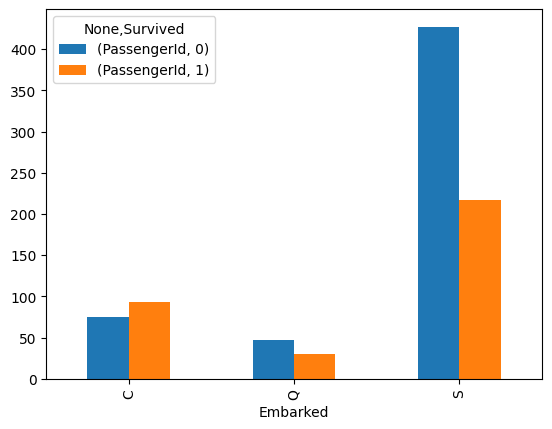

In [16]:
embarked_df = TRAIN[['Embarked', 'Survived', 'PassengerId']].dropna().groupby(['Embarked', 'Survived']).count().unstack()

embarked_df.plot.bar(stacked=False)

<Axes: xlabel='Sex'>

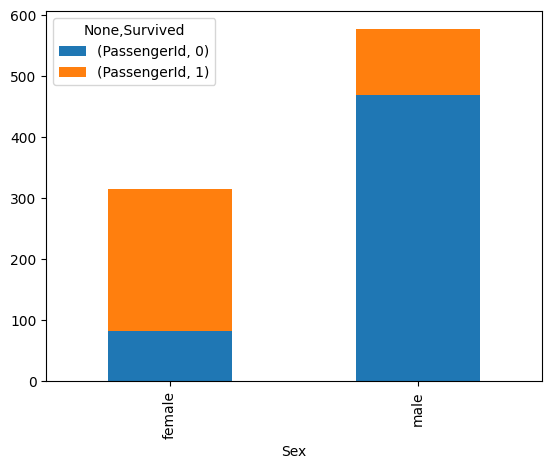

In [17]:
TRAIN[['Sex', 'Survived', 'PassengerId']].dropna().groupby(['Sex', 'Survived']).count().unstack().plot.bar(stacked=True)

- plot columns
- Catergorical -> numeric

In [21]:
TRAIN = pd.get_dummies(TRAIN, columns=['Sex'], drop_first=True)
TRAIN = pd.get_dummies(TRAIN, columns=['Pclass', 'Embarked'], drop_first=False)
TRAIN.tail(3)

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.45,NaN,False,False,False,True,False,False,True
889,890,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.00,C148,True,True,False,False,True,False,False
890,891,0,"Dooley, Mr. Patrick",32.0,0,0,370376,7.75,NaN,True,False,False,True,False,True,False


In [22]:
train = TRAIN.copy()
train.drop(
    columns=['PassengerId', 'Name', 'Ticket', ], inplace=True
)
train.tail(3)

,Survived,Age,SibSp,Parch,Fare,Cabin,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
888,0,NaN,1,2,23.45,NaN,False,False,False,True,False,False,True
889,1,26.0,0,0,30.00,C148,True,True,False,False,True,False,False
890,0,32.0,0,0,7.75,NaN,True,False,False,True,False,True,False


<Axes: >

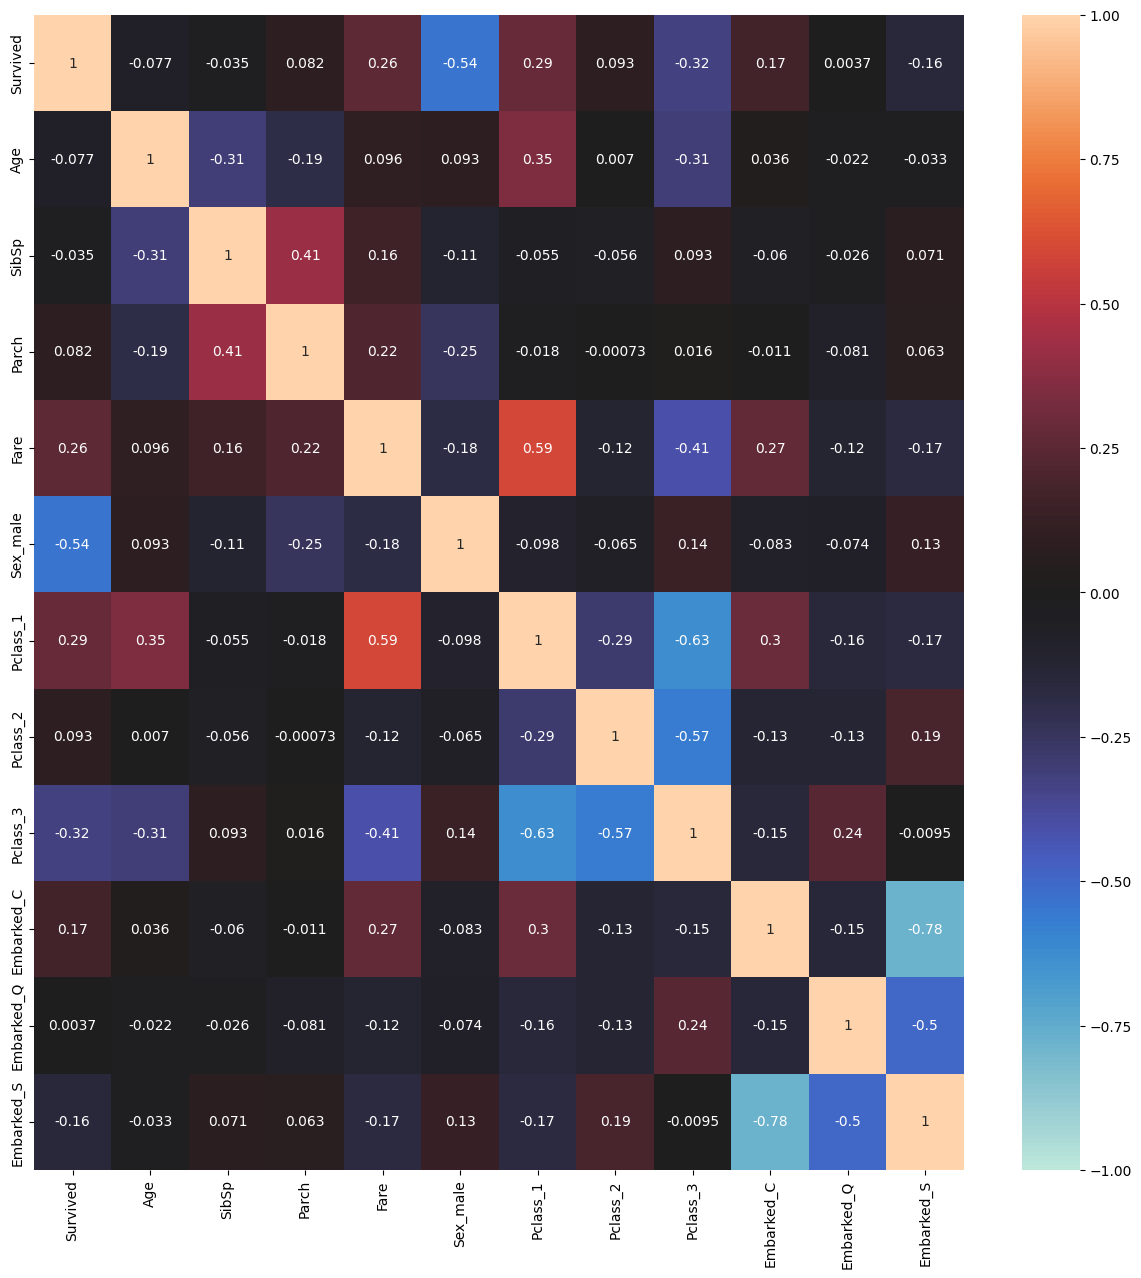

In [23]:
corr_data = train.drop(['Cabin'], axis=1).corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_data, vmax=1, vmin=-1, center=0, annot=True)

## pre-processing

추가로 알 수 있는 정보, 가능하면 추가해보자.
- Name값에서 결혼 유무 새컬럼 만들기
- Cabin의 위치

In [32]:
train.drop(['Cabin', ], axis=1, inplace=True)
train.tail(3)

,Survived,Age,SibSp,Parch,Fare,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
888,0,NaN,1,2,23.45,False,False,False,True,False,False,True
889,1,26.0,0,0,30.00,True,True,False,False,True,False,False
890,0,32.0,0,0,7.75,True,False,False,True,False,True,False


In [48]:
train['Age'] = train['Age'].fillna(train['Age'].mean())

In [61]:
from sklearn.model_selection import train_test_split
pd.set_option("display.max_columns", 100)

X = train.iloc[:, 1:]
Y = train.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=400)
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score,auc

print(confusion_matrix(y_preds, y_test))

print(f'Acc: {accuracy_score(y_preds, y_test) * 100:.2f} %')

[[90 21]
 [15 53]]
Acc: 79.89 %
